# Sujet 6.2 - Files d'Attente en Centre Hospitalier (M/M/c)

**Universite de Nouakchott Al Aasriya (UNA)**  
Module : Recherche Operationnelle - Licence 2025/2026  
Responsable : Dr. EL BENANY Med Mahmoud  
Etudiant : Malick Tounkara

---

## Objectif

Ce notebook modelise les urgences d'un centre hospitalier a Nouakchott avec le modele **M/M/c**.
On cherche le **nombre optimal de medecins** c qui garantit un temps d'attente inferieur a 15 minutes.

---
## 1. Importation des bibliotheques

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import factorial

np.random.seed(42)
print('Bibliotheques importees avec succes !')

Bibliotheques importees avec succes !


---
## 2. Parametres du systeme hospitalier

- lambda = 10 patients/heure (taux d'arrivee aux urgences)
- mu = 4 patients/heure par medecin (taux de service)
- Wmax = 15 minutes (seuil d'attente acceptable)

**Condition de stabilite :** rho = lambda / (c x mu) < 1

Donc : c > lambda/mu = 10/4 = 2.5 => c >= 3 medecins minimum

---
## 3. Formules analytiques M/M/c

**Probabilite systeme vide (P0) :**

P0 = 1 / [ somme(n=0 a c-1) de (a^n / n!) + a^c / (c! x (1-rho)) ]

ou a = lambda/mu

**Formule d'Erlang C :**

C(c, rho) = [ a^c / (c! x (1-rho)) ] x P0

**Indicateurs de performance :**

Wq = C(c,rho) / (c x mu - lambda)

Lq = lambda x Wq

W = Wq + 1/mu

In [3]:
# ============================================================
# PARAMETRES
# ============================================================
lambda_ = 10      # taux d'arrivee (patients/heure)
mu      = 4       # taux de service par medecin (patients/heure)
Wmax    = 15/60   # seuil max (15 min converti en heures)


def indicateurs_mmc(lambda_, mu, c):
    """
    Calcule les indicateurs M/M/c.
    Retourne None si systeme instable.
    """
    rho = lambda_ / (c * mu)
    if rho >= 1:
        return None

    a = lambda_ / mu

    # Calcul P0
    somme = sum(a**n / factorial(n) for n in range(c))
    somme += a**c / (factorial(c) * (1 - rho))
    P0 = 1 / somme

    # Erlang C
    Cc = (a**c / (factorial(c) * (1 - rho))) * P0

    # Indicateurs
    Wq = Cc / (c * mu - lambda_)
    Lq = lambda_ * Wq
    W  = Wq + 1/mu
    L  = lambda_ * W

    return {
        'c'      : c,
        'rho'    : rho,
        'P0'     : P0,
        'Cc'     : Cc,
        'Lq'     : Lq,
        'L'      : L,
        'Wq_min' : Wq * 60,
        'W_min'  : W  * 60
    }


print('Fonction M/M/c definie avec succes !')

Fonction M/M/c definie avec succes !


---
## 4. Comparaison selon le nombre de medecins

In [4]:
resultats = []
c_optimal = None

for c in range(1, 7):
    res = indicateurs_mmc(lambda_, mu, c)
    if res is None:
        resultats.append({
            'c': c, 'rho': 'instable', 'Lq': 'infini',
            'Wq (min)': 'infini', 'W (min)': 'infini',
            'Stable': 'NON', 'Wq<=15min': 'NON'
        })
    else:
        ok = 'OUI' if res['Wq_min'] <= 15 else 'NON'
        if ok == 'OUI' and c_optimal is None:
            c_optimal = c
        resultats.append({
            'c'        : c,
            'rho'      : round(res['rho'], 3),
            'Lq'       : round(res['Lq'], 3),
            'Wq (min)' : round(res['Wq_min'], 2),
            'W (min)'  : round(res['W_min'], 2),
            'Stable'   : 'OUI',
            'Wq<=15min': ok
        })

df = pd.DataFrame(resultats)
print('=' * 65)
print('   COMPARAISON M/M/c - URGENCES HOPITAL NOUAKCHOTT')
print('=' * 65)
print(df.to_string(index=False))
print('=' * 65)
print('\n>>> SOLUTION OPTIMALE : c* =', c_optimal, 'medecins')

   COMPARAISON M/M/c - URGENCES HOPITAL NOUAKCHOTT
 c      rho     Lq Wq (min) W (min) Stable Wq<=15min
 1 instable infini   infini  infini    NON       NON
 2 instable infini   infini  infini    NON       NON
 3    0.833  3.511    21.07   36.07    OUI       NON
 4    0.625  0.533      3.2    18.2    OUI       OUI
 5      0.5   0.13     0.78   15.78    OUI       OUI
 6    0.417  0.034      0.2    15.2    OUI       OUI

>>> SOLUTION OPTIMALE : c* = 4 medecins


---
## 5. Visualisations

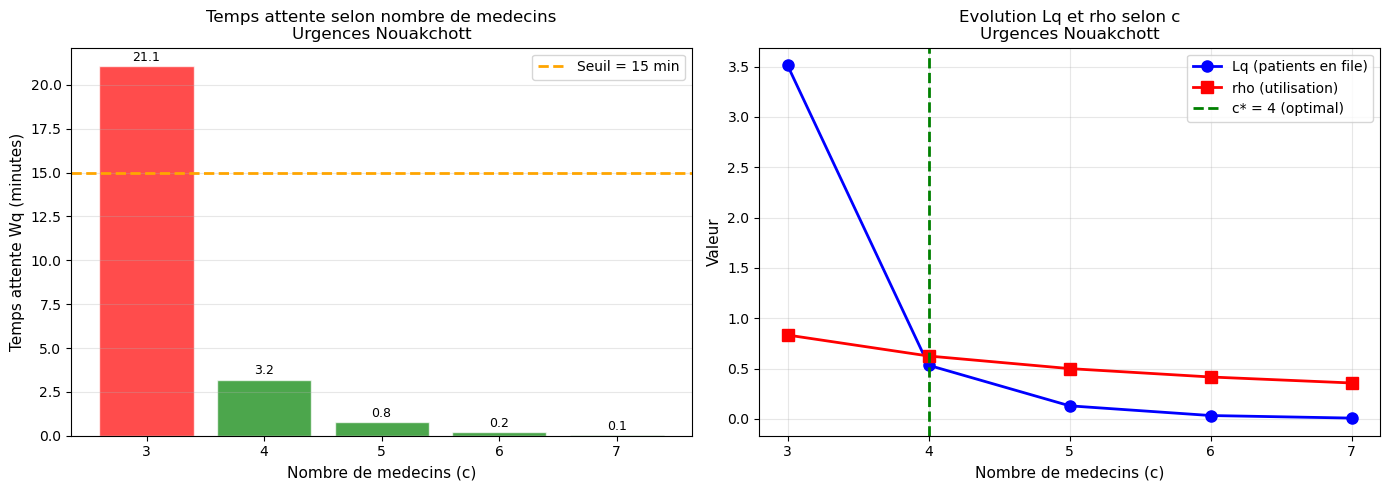

Graphique sauvegarde : hopital_mmc.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

serveurs = list(range(3, 8))
wqs, lqs, rhos = [], [], []

for c in serveurs:
    res = indicateurs_mmc(lambda_, mu, c)
    wqs.append(res['Wq_min'])
    lqs.append(res['Lq'])
    rhos.append(res['rho'])

# --- Graphique 1 : Wq selon c ---
ax1 = axes[0]
colors = ['green' if w <= 15 else 'red' for w in wqs]
bars = ax1.bar(serveurs, wqs, color=colors, alpha=0.7, edgecolor='white')
ax1.axhline(15, color='orange', linestyle='--', linewidth=2, label='Seuil = 15 min')
ax1.set_xlabel('Nombre de medecins (c)', fontsize=11)
ax1.set_ylabel('Temps attente Wq (minutes)', fontsize=11)
ax1.set_title('Temps attente selon nombre de medecins\nUrgences Nouakchott', fontsize=12)
ax1.legend(fontsize=10)
ax1.set_xticks(serveurs)
for bar, val in zip(bars, wqs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# --- Graphique 2 : Lq et rho selon c ---
ax2 = axes[1]
ax2.plot(serveurs, lqs,  'b-o', linewidth=2, markersize=8, label='Lq (patients en file)')
ax2.plot(serveurs, rhos, 'r-s', linewidth=2, markersize=8, label='rho (utilisation)')
ax2.axvline(c_optimal, color='green', linestyle='--', linewidth=2,
            label='c* = ' + str(c_optimal) + ' (optimal)')
ax2.set_xlabel('Nombre de medecins (c)', fontsize=11)
ax2.set_ylabel('Valeur', fontsize=11)
ax2.set_title('Evolution Lq et rho selon c\nUrgences Nouakchott', fontsize=12)
ax2.legend(fontsize=10)
ax2.set_xticks(serveurs)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hopital_mmc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegarde : hopital_mmc.png')

---
## 6. Analyse de la solution optimale

In [6]:
res = indicateurs_mmc(lambda_, mu, c_optimal)

print('=' * 55)
print('   SOLUTION OPTIMALE : c* =', c_optimal, 'MEDECINS')
print('=' * 55)
print('  Lambda              :', lambda_, 'patients/h')
print('  Mu                  :', mu, 'patients/h par medecin')
print('  c optimal           :', c_optimal)
print('-' * 55)
print('  rho (utilisation)   :', round(res['rho'], 4), '=', round(res['rho']*100, 1), '%')
print('  P0 (systeme vide)   :', round(res['P0'], 4))
print('  Erlang C            :', round(res['Cc'], 4))
print('-' * 55)
print('  Lq (en file)        :', round(res['Lq'], 4), 'patients')
print('  L  (dans systeme)   :', round(res['L'],  4), 'patients')
print('-' * 55)
print('  Wq (attente file)   :', round(res['Wq_min'], 2), 'min  <= 15 min OK')
print('  W  (temps systeme)  :', round(res['W_min'],  2), 'min')
print('=' * 55)
print('\nCONCLUSION :', c_optimal, 'medecins suffisent pour garantir')
print('une attente <= 15 min aux urgences de Nouakchott.')

   SOLUTION OPTIMALE : c* = 4 MEDECINS
  Lambda              : 10 patients/h
  Mu                  : 4 patients/h par medecin
  c optimal           : 4
-------------------------------------------------------
  rho (utilisation)   : 0.625 = 62.5 %
  P0 (systeme vide)   : 0.0737
  Erlang C            : 0.3199
-------------------------------------------------------
  Lq (en file)        : 0.5331 patients
  L  (dans systeme)   : 3.0331 patients
-------------------------------------------------------
  Wq (attente file)   : 3.2 min  <= 15 min OK
  W  (temps systeme)  : 18.2 min

CONCLUSION : 4 medecins suffisent pour garantir
une attente <= 15 min aux urgences de Nouakchott.


---
## 7. Conclusion

### Points cles retenus

- Le modele **M/M/c** etend M/M/1 a plusieurs serveurs
- La condition de stabilite devient : rho = lambda / (c x mu) < 1
- La **formule d'Erlang C** donne la probabilite d'attente
- Le nombre optimal de medecins est le plus petit c tel que Wq <= Wmax
- Ce modele est directement applicable aux urgences en Mauritanie

---
*Sujet 6.2 - Problemes reels (RIM) - obligatoire - RO 2025/2026*